 ## Importing Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sqlite3
from scipy.stats import ttest_ind
import scipy.stats as stats
warnings.filterwarnings('ignore')

In [3]:
# Creating database connection
conn = sqlite3.connect('inventory.db')

# Fetching vendor summary data
df = pd.read_sql_query("select * from vendor_sales_summary", conn)
df.head()

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalestoPurchasRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750,145080,3811251.60,139150.0,5000483.50,661902.43,255672.60,68601.68,1189231.90,23.782338,0.959126,1.312032
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750,164038,3804041.22,155918.0,4693575.78,552380.52,286484.41,144929.24,889534.56,18.952172,0.950499,1.233839
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750,187407,3418303.68,183423.0,4450808.27,453458.92,337024.30,123780.22,1032504.59,23.198137,0.978741,1.302052
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750,201682,3261197.94,194014.0,4341678.86,413459.15,356486.75,257032.07,1080480.92,24.886247,0.961980,1.331314
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750,138109,3023206.01,132388.0,4119642.12,535791.61,243248.68,257032.07,1096436.11,26.614839,0.958576,1.362673


### Exploratry Data Analysis

* Previously, we examined the various tables in the database to identify key variables, understand their relationship, and determine which ones should be include in the final analysis

* In this phase of EDA, we will analyze the resultant table to gain insights into the distribution of each column.This will help will us understand data patterns,identify anomalies,and ensure data quality before proceeding with further analysis.

In [4]:
# summary statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
VendorNumber,10692.0,10650.649458,18753.519148,2.000000,3951.000000,7153.000000,9552.000000,2.013590e+05
Brand,10692.0,18039.228769,12662.187074,58.000000,5793.500000,18761.500000,25514.250000,9.063100e+04
PurchasePrice,10692.0,24.385303,109.269375,0.360000,6.840000,10.455000,19.482500,5.681810e+03
ActualPrice,10692.0,35.643671,148.246016,0.490000,10.990000,15.990000,28.990000,7.499990e+03
TotalPurchaseQuantity,10692.0,3140.886831,11095.086769,1.000000,36.000000,262.000000,1975.750000,3.376600e+05
TotalPurchaseDollars,10692.0,30106.693372,123067.799627,0.710000,453.457500,3655.465000,20738.245000,3.811252e+06
TotalSalesQuantity,10485.0,3047.289366,10766.571568,1.000000,36.000000,274.000000,1940.000000,3.267250e+05
TotalSalesDollars,10485.0,41788.215542,164795.142338,4.990000,791.470000,5462.190000,28693.970000,5.000484e+06
TotalSalesPrice,10485.0,18619.964763,44231.174162,1.470000,323.860000,2922.150000,16020.530000,6.619024e+05
TotalExciseTax,10485.0,1761.939613,10818.010330,0.060000,5.290000,49.250000,423.220000,3.564868e+05


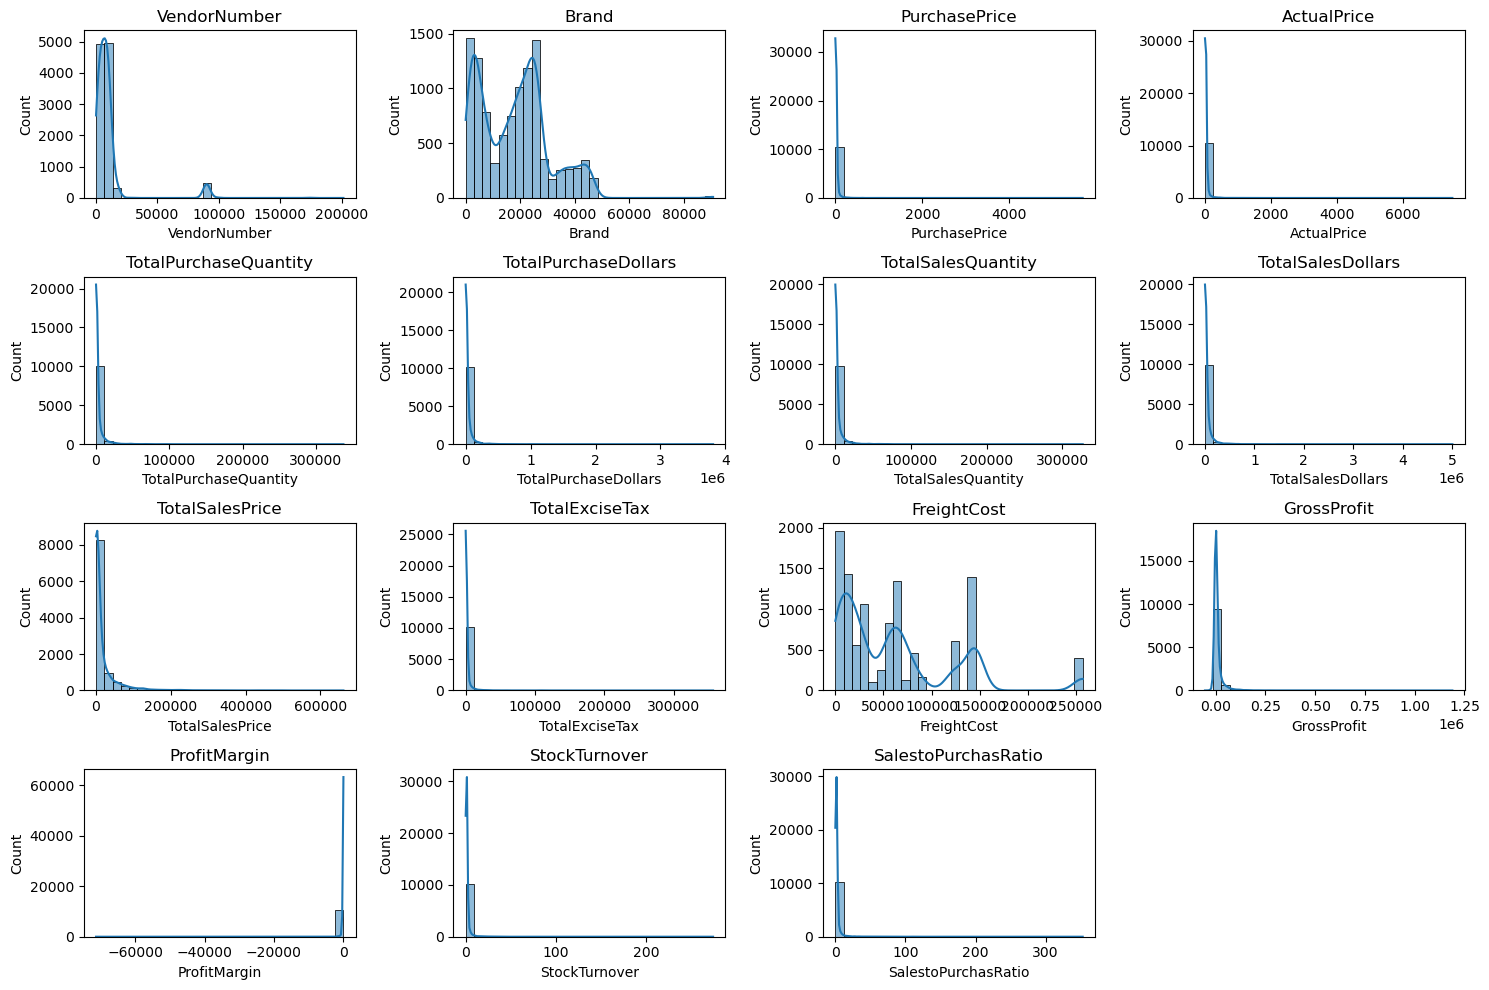

In [7]:
# Distrubution plots for Numerical Columns
numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i+1) # Adjust grid layout as needed
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()

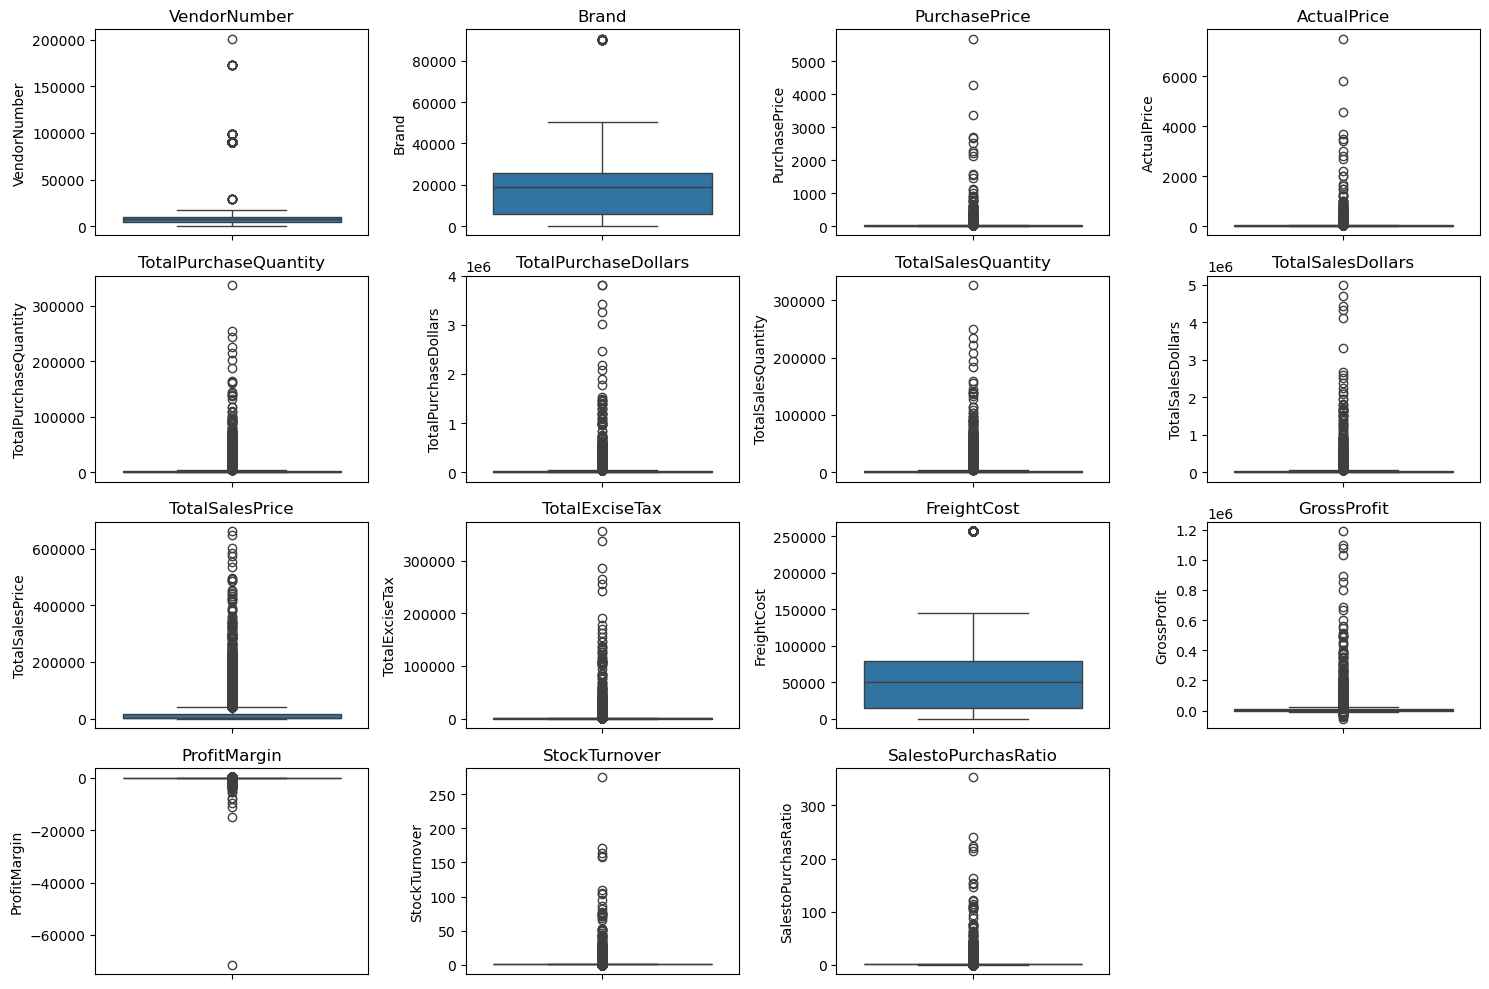

In [10]:
# Outlier Detection with Boxplots
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i+1)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()


# Summary Statistics Insights :

## *Negative & Zero Values:*

* Gross Profit: Minimum value is -52,002.78,indicating losses.Some products or transactions may be slling at a loss due to high costs or selling 
     at discounts lower than the purchase price.

* profit Margin:Has a minimum of ,which suggests cases where revenue is zero or even lower than costs.

* Total sales Quantity & Sales Dollars:Minimum values are 0, mening some products were purchased but never sold.These could be slow-moving or 
        absolete stock

## *Outliers Indicated by High Standard Deviations:*

* Purchase & Actual Prices:The max values(5,681.81 & 7,499.99) are significantly higher than the mean (24.39 & 35.64),indicating potential 
        premium products.

* Freight Cost:Huge variation,from 0.09 to 257,032.07,suggests logistics ineffciencies or bulk shipments.

* Stock Turnover:Ranges from 0 to 274.5,implying some products sell extremely fast whille others remain in stock indefinitely.Value more then 1
        indicates that sold quantity for the product is higher than purchased quanitity due to either sales are being fulfilled from older stock.

In [12]:
# let's filter the data by removing inconsistencies
df = pd.read_sql_query("""SELECT * 
FROM vendor_sales_summary
WHERE GrossProfit > 0
AND ProfitMargin > 0
AND TotalSalesQuantity > 0""",conn)

In [13]:
df

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalestoPurchasRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750,145080,3811251.60,139150.0,5000483.50,661902.43,255672.60,68601.68,1189231.90,23.782338,0.959126,1.312032
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750,164038,3804041.22,155918.0,4693575.78,552380.52,286484.41,144929.24,889534.56,18.952172,0.950499,1.233839
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750,187407,3418303.68,183423.0,4450808.27,453458.92,337024.30,123780.22,1032504.59,23.198137,0.978741,1.302052
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750,201682,3261197.94,194014.0,4341678.86,413459.15,356486.75,257032.07,1080480.92,24.886247,0.961980,1.331314
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750,138109,3023206.01,132388.0,4119642.12,535791.61,243248.68,257032.07,1096436.11,26.614839,0.958576,1.362673
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8392,3960,DIAGEO NORTH AMERICA INC,2626,Crown Royal Apple,1.42,1.99,50,2,2.84,14.0,27.86,5.97,0.73,257032.07,25.02,89.806174,7.000000,9.809859
8393,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,1.32,4.99,750,2,2.64,5.0,15.95,10.96,0.55,27100.41,13.31,83.448276,2.500000,6.041667
8394,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.39,0.49,50,6,2.34,134.0,65.66,1.47,7.04,50293.62,63.32,96.436186,22.333333,28.059829
8395,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.47,1.99,200,1,1.47,69.0,137.31,71.64,14.49,257032.07,135.84,98.929430,69.000000,93.408163


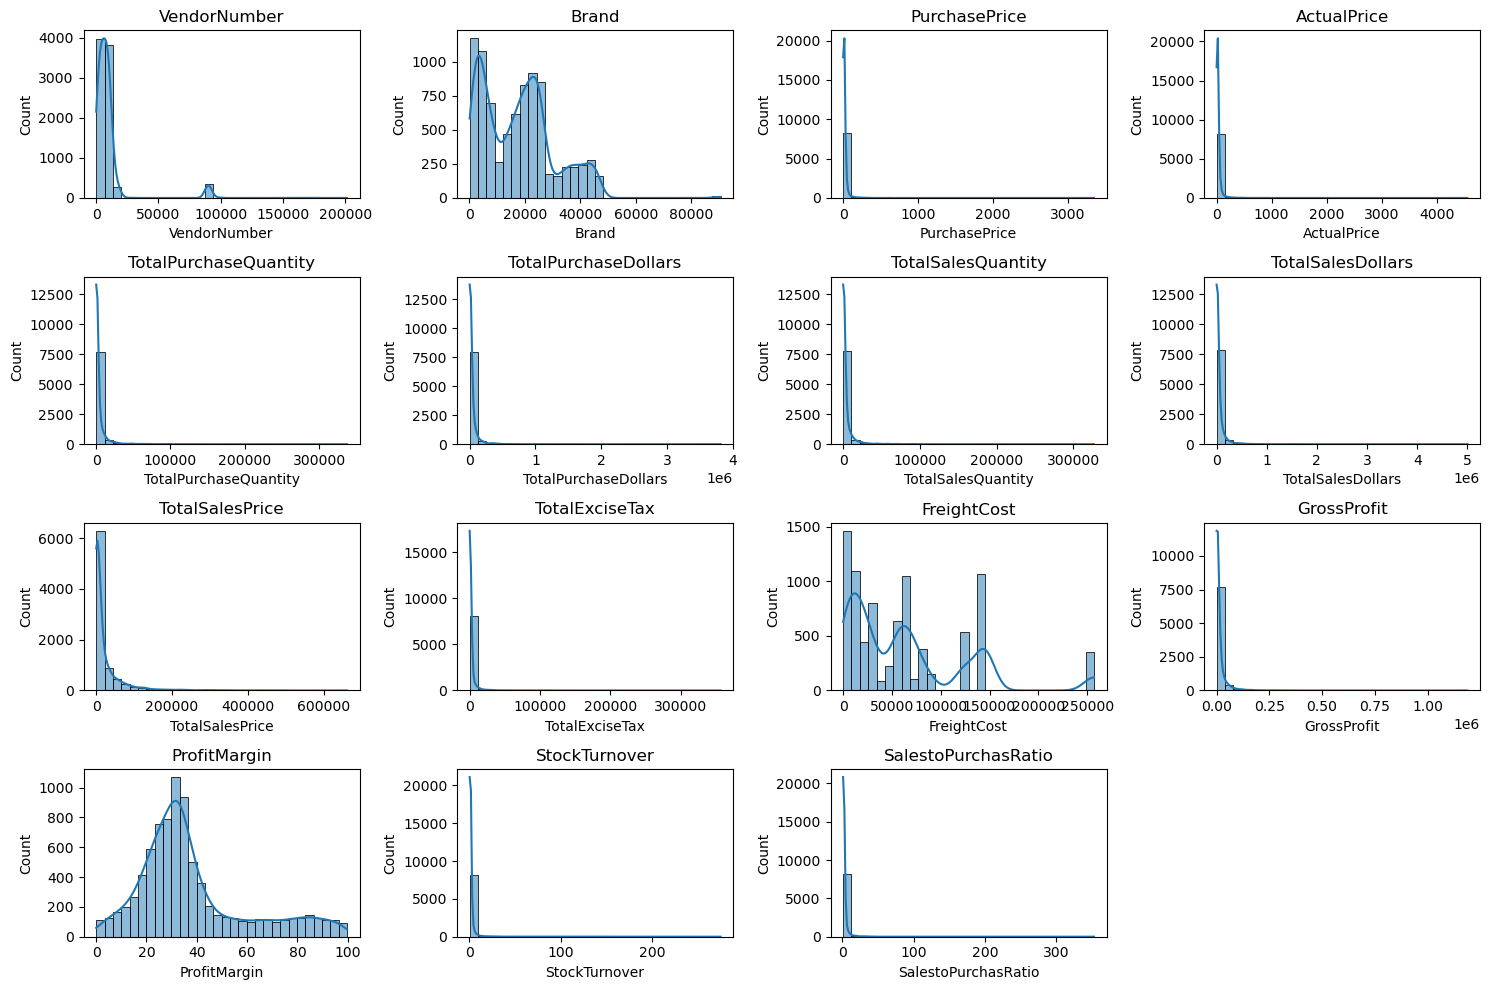

In [14]:
# Distrubution plots for Numerical Columns
numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i+1) # Adjust grid layout as needed
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()

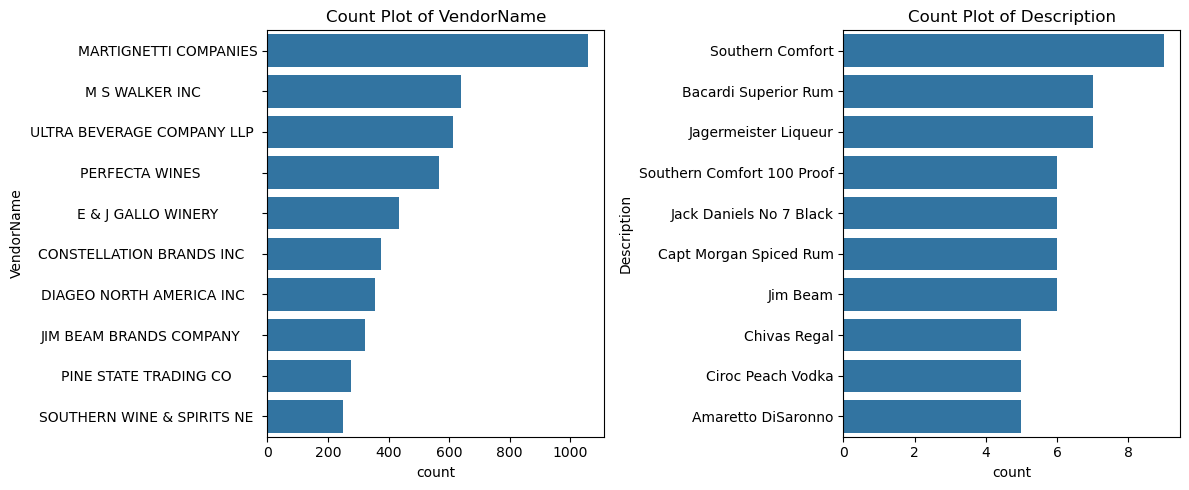

In [17]:
# Count plots for Categorical Columns
categorical_cols = ["VendorName","Description"]

plt.figure(figsize=(12, 5))
for i, col in enumerate(categorical_cols):
    plt.subplot(1, 2, i+1)
    sns.countplot(y=df[col], order=df[col].value_counts().index[:10]) # Top 10 categories
    plt.title(f"Count Plot of {col}")
plt.tight_layout()
plt.show()

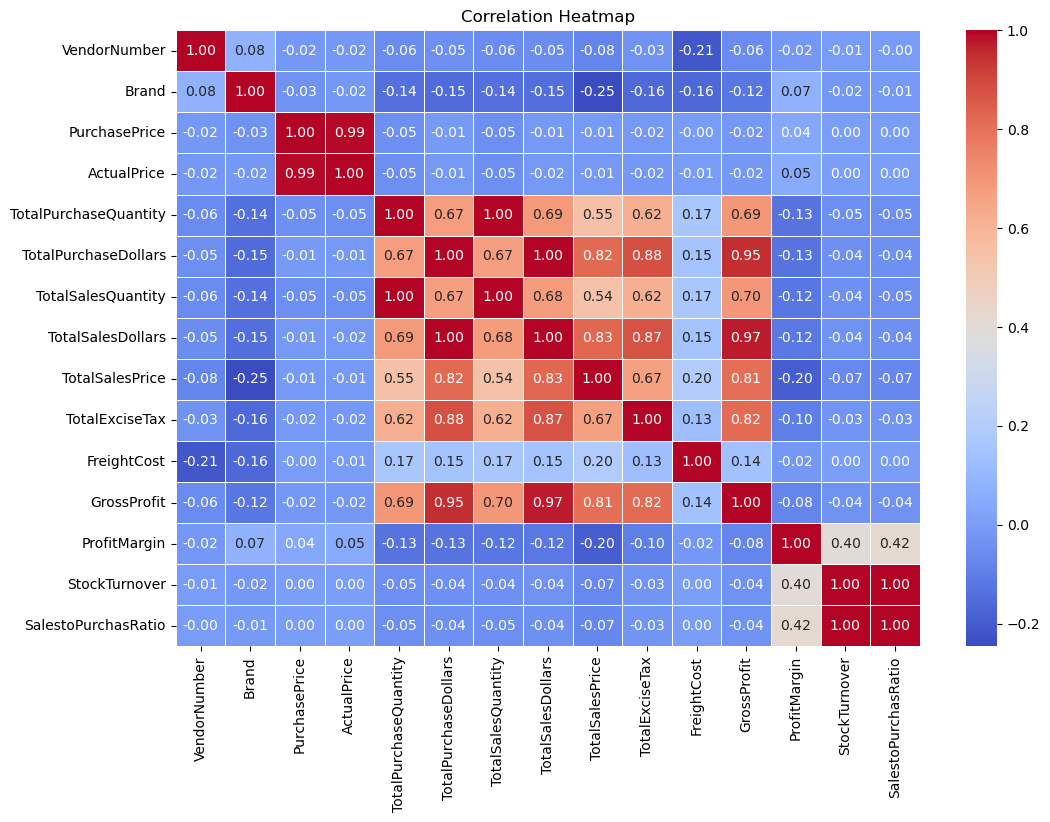

In [20]:
# Correlation Heatmap
plt.figure(figsize=(12, 8))
correlation_matrix = df[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

## Correlation Insights

* PurchasePrice has weak corrlations with TotalSalesDollars(-0.012)and GrossProfit(-0.016),suggesting that price variations do not significantly
    impact sales revenue or profit.

* Strong correlation between total purchase quantity and total sales quantity(0.999),confirming efficient inventory turnover.

* Negative correlation between profit margin & total sales price(-0.179)suggests that as sales price inreases, margins decrease,possibly due to
    comptitve pricing pressures.

* StockTurnover has weak negative correlations with both GrossProfit(-0.038)and ProfitMargin(-0.055),indicating that faster turnover does not 
    necessarily result in higher profitability.

## Data Analytics

#### dentify Brands that needs Promotional or Pricing Adjustments Which exhibit lower sales performance but higher profit margins.

In [22]:
brand_performance = df.groupby('Description').agg({
    'TotalSalesDollars':'sum',
    'ProfitMargin':'mean'}).reset_index()

In [23]:
low_sales_threshold = brand_performance['TotalSalesDollars'].quantile(0.15)
high_margin_threshold = brand_performance['ProfitMargin'].quantile(0.85)

In [26]:
print(low_sales_threshold)

558.5699999999999


In [25]:
print(high_margin_threshold)

65.49086974324325


In [28]:
# Filter brands with low sales but high profit margins
target_brands = brand_performance[
    (brand_performance['TotalSalesDollars'] <= low_sales_threshold) & (brand_performance['ProfitMargin'] <= high_margin_threshold)
]
print("brands with Low Sales but High Profit Margins:")
display(target_brands.sort_values('TotalSalesDollars'))

brands with Low Sales but High Profit Margins:


,Description,TotalSalesDollars,ProfitMargin
6819,Terruzzi & Puthod Vernaccia,4.99,32.464930
145,Albero Sparkling Wh Organic,5.79,28.497409
2844,Firefly Ridge Chard,5.79,31.088083
6372,Smirnoff Light Strawberry,5.94,50.168350
175,Allen's Blue Curacao Liqueur,5.99,20.033389
...,...,...,...
3080,Gallo Pnt Nr Pavia,557.46,35.485954
232,Andre Moscato,558.04,23.446348
4210,Lamberti Prosecco Extra Dry,558.40,29.899713
4244,Latour L'Ardeche Chard,558.57,12.992105


In [34]:
brand_performance = brand_performance[brand_performance['TotalSalesDollars']<10000]

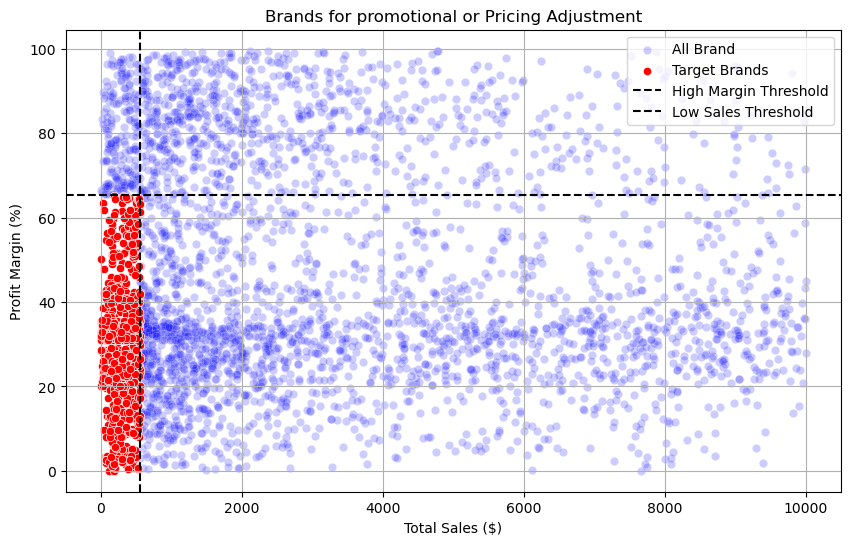

In [35]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=brand_performance, x='TotalSalesDollars', y='ProfitMargin', color="blue", label="All Brand", alpha = 0.2)
sns.scatterplot(data=target_brands, x='TotalSalesDollars', y='ProfitMargin', color="red", label="Target Brands")

plt.axhline(high_margin_threshold, linestyle='--', color='black', label="High Margin Threshold")
plt.axvline(low_sales_threshold, linestyle='--', color='black', label="Low Sales Threshold")

plt.xlabel("Total Sales ($)")
plt.ylabel("Profit Margin (%)")
plt.title("Brands for promotional or Pricing Adjustment")
plt.legend()
plt.grid(True)
plt.show()

#### Which vendors and brands demonstrate the highest sales performance ?

In [40]:
def fromat_dollars(value):
    if value >= 1_000_000:
        return f"{value / 1_000_000:.2f}M"
    elif value >= 1_000:
        return f"{value / 1_000:.2f}k"
    else:
        return str(value)

In [36]:
# Top Vendors & Brands by Sales Performance
top_vendors = df.groupby("VendorName")["TotalSalesDollars"].sum().nlargest(10)
top_brands = df.groupby("Description")["TotalSalesDollars"].sum().nlargest(10)
top_vendors

VendorName
DIAGEO NORTH AMERICA INC       65427358.47
MARTIGNETTI COMPANIES          37886115.99
PERNOD RICARD USA              30917649.71
JIM BEAM BRANDS COMPANY        30236142.52
BACARDI USA INC                24202988.62
CONSTELLATION BRANDS INC       23490743.51
E & J GALLO WINERY             17822300.36
BROWN-FORMAN CORP              17381361.93
ULTRA BEVERAGE COMPANY LLP     15905227.00
M S WALKER INC                 14183849.38
Name: TotalSalesDollars, dtype: float64

In [41]:
top_brands

Description
Jack Daniels No 7 Black    7782908.55
Tito's Handmade Vodka      7190281.74
Grey Goose Vodka           7045707.78
Capt Morgan Spiced Rum     6156581.52
Absolut 80 Proof           6111467.36
Jameson Irish Whiskey      5510493.47
Ketel One Vodka            4939912.54
Baileys Irish Cream        3932179.19
Kahlua                     3473027.12
Tanqueray                  3379734.86
Name: TotalSalesDollars, dtype: float64

In [43]:
top_brands.apply(lambda x : fromat_dollars(x))

Description
Jack Daniels No 7 Black    7.78M
Tito's Handmade Vodka      7.19M
Grey Goose Vodka           7.05M
Capt Morgan Spiced Rum     6.16M
Absolut 80 Proof           6.11M
Jameson Irish Whiskey      5.51M
Ketel One Vodka            4.94M
Baileys Irish Cream        3.93M
Kahlua                     3.47M
Tanqueray                  3.38M
Name: TotalSalesDollars, dtype: object

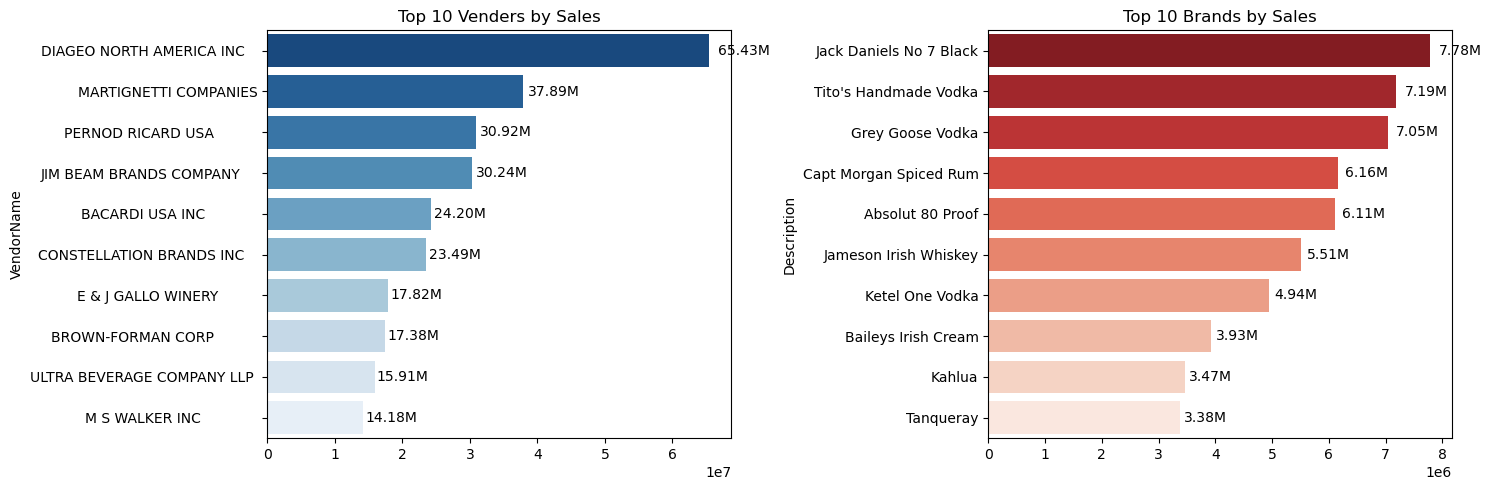

In [48]:
plt.figure(figsize=(15, 5))

# plot for Top Vendors 
plt.subplot(1, 2, 1)
ax1 = sns.barplot(y=top_vendors.index, x=top_vendors.values, palette="Blues_r")
plt.title("Top 10 Venders by Sales")

for bar in ax1.patches:
    ax1.text(bar.get_width() + (bar.get_width() * 0.02),
             bar.get_y() + bar.get_height() / 2,
             fromat_dollars(bar.get_width()),
             ha='left', va='center', fontsize=10, color='black')

# plot for Top Brands
plt.subplot(1, 2, 2)
ax2 = sns.barplot(y=top_brands.index.astype(str), x=top_brands.values, palette="Reds_r")
plt.title("Top 10 Brands by Sales")

for bar in ax2.patches:
    ax2.text(bar.get_width() + (bar.get_width() * 0.02),
             bar.get_y() + bar.get_height() / 2,
             fromat_dollars(bar.get_width()),
             ha='left', va='center', fontsize=10, color='black')

plt.tight_layout()
plt.show()

### Which vendors contribute the most to total purchase dollars?

In [50]:
Vendor_Performance = df.groupby('VendorName').agg({'TotalPurchaseDollars':'sum','GrossProfit':'sum','TotalSalesDollars':'sum'}).reset_index()

In [65]:
Vendor_Performance['PurchaseConribution%'] = Vendor_Performance['TotalPurchaseDollars'] / Vendor_Performance['TotalPurchaseDollars'].sum()*100

In [68]:
Vendor_Performance = round(Vendor_Performance.sort_values('PurchaseConribution%', ascending = False),2)

In [69]:
# Display Top 10 Vendors
top_vendors = Vendor_Performance.head(10)
top_vendors['TotalSalesDollars'] = top_vendors['TotalSalesDollars'].apply(fromat_dollars)
top_vendors['TotalPurchaseDollars'] = top_vendors['TotalPurchaseDollars'].apply(fromat_dollars)
top_vendors['GrossProfit'] = top_vendors['GrossProfit'].apply(fromat_dollars)

top_vendors

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseConribution%
25,DIAGEO NORTH AMERICA INC,49.57M,15.86M,65.43M,16.29
57,MARTIGNETTI COMPANIES,25.25M,12.64M,37.89M,8.29
69,PERNOD RICARD USA,23.70M,7.22M,30.92M,7.79
46,JIM BEAM BRANDS COMPANY,23.13M,7.11M,30.24M,7.60
6,BACARDI USA INC,17.38M,6.82M,24.20M,5.71
20,CONSTELLATION BRANDS INC,15.19M,8.30M,23.49M,4.99
11,BROWN-FORMAN CORP,12.91M,4.48M,17.38M,4.24
30,E & J GALLO WINERY,12.02M,5.80M,17.82M,3.95
107,ULTRA BEVERAGE COMPANY LLP,11.01M,4.90M,15.91M,3.62
80,SAZERAC CO INC,9.70M,3.00M,12.71M,3.19


In [70]:
top_vendors['Cumulative_Contribution%'] = top_vendors['PurchaseConribution%'].cumsum()
top_vendors

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseConribution%,Cumulative_Contribution%
25,DIAGEO NORTH AMERICA INC,49.57M,15.86M,65.43M,16.29,16.29
57,MARTIGNETTI COMPANIES,25.25M,12.64M,37.89M,8.29,24.58
69,PERNOD RICARD USA,23.70M,7.22M,30.92M,7.79,32.37
46,JIM BEAM BRANDS COMPANY,23.13M,7.11M,30.24M,7.60,39.97
6,BACARDI USA INC,17.38M,6.82M,24.20M,5.71,45.68
20,CONSTELLATION BRANDS INC,15.19M,8.30M,23.49M,4.99,50.67
11,BROWN-FORMAN CORP,12.91M,4.48M,17.38M,4.24,54.91
30,E & J GALLO WINERY,12.02M,5.80M,17.82M,3.95,58.86
107,ULTRA BEVERAGE COMPANY LLP,11.01M,4.90M,15.91M,3.62,62.48
80,SAZERAC CO INC,9.70M,3.00M,12.71M,3.19,65.67


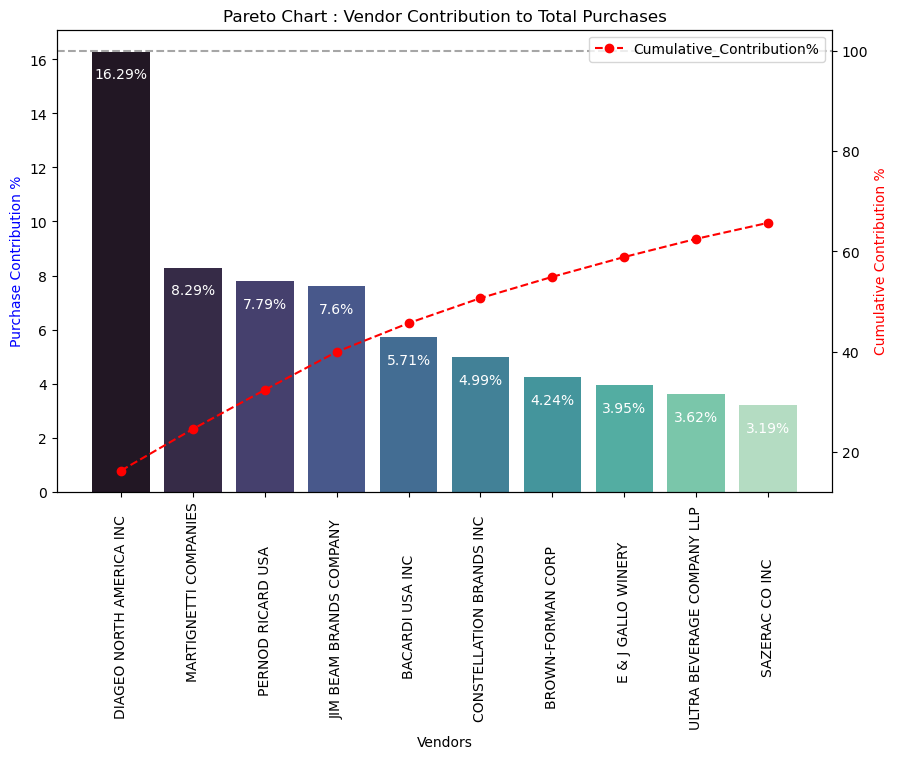

In [71]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar plot for Purchase Contribution%
sns.barplot(x=top_vendors['VendorName'], y=top_vendors['PurchaseConribution%'], palette="mako", ax=ax1)

for i, value in enumerate(top_vendors['PurchaseConribution%']):
    ax1.text(i,  value - 1, str(value)+'%', ha='center', fontsize=10, color='white')

# Line plot for Cumulative Contribution%
ax2 = ax1.twinx()
ax2.plot(top_vendors['VendorName'], top_vendors['Cumulative_Contribution%'], color='red', marker='o', linestyle='dashed', label='Cumulative_Contribution%')

ax1.set_xticklabels(top_vendors['VendorName'], rotation=90)
ax1.set_ylabel('Purchase Contribution %', color='blue')
ax2.set_ylabel('Cumulative Contribution %', color='red')
ax1.set_xlabel('Vendors')
ax1.set_title('Pareto Chart : Vendor Contribution to Total Purchases')

ax2.axhline(y=100, color='gray', linestyle='dashed', alpha=0.7)
ax2.legend(loc='upper right')

plt.show()

### How much of total procurement is dependent on the top vendors?

In [79]:
print(f"Total Purchase Contribution of top 10 vendors is {round(top_vendors['PurchaseConribution%'].sum(),2)}%")

Total Purchase Contribution of top 10 vendors is 65.67%


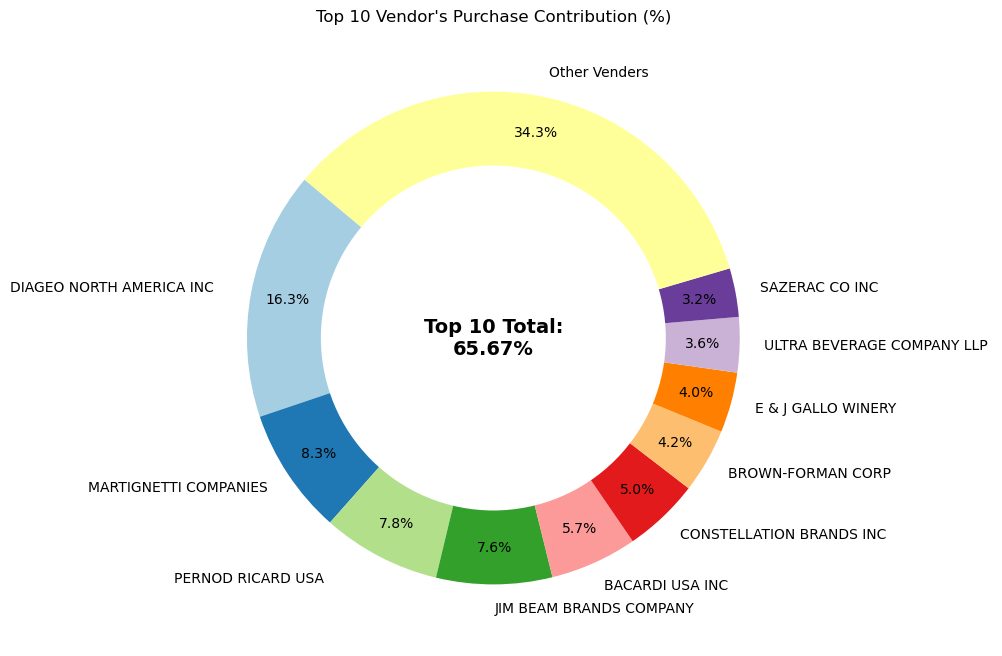

In [82]:
vendors = list(top_vendors['VendorName'].values)
purchase_contribution = list(top_vendors['PurchaseConribution%'].values)
total_contribution = sum(purchase_contribution)
remaining_contribution = 100 - total_contribution

# Append "other Vendors" category
vendors.append("Other Venders")
purchase_contribution.append(remaining_contribution)

# Donut Chart
fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(purchase_contribution, labels=vendors, autopct='%1.1f%%',
                                  startangle=140, pctdistance=0.85, colors=plt.cm.Paired.colors)

# Draw a white circle in the center to create a "donut" effect
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig.gca().add_artist(centre_circle)

# Add Total Contribution annotation in the center
plt.text(0, 0, f"Top 10 Total:\n{total_contribution:.2f}%", fontsize=14, fontweight='bold', ha='center', va='center')

plt.title("Top 10 Vendor's Purchase Contribution (%)")
plt.show()

#### Does purchasing in bulk reduce the unit price,and what is the optimal purchase volume for cost savings?

In [83]:
df['UnitPurchasePrice'] = df['TotalPurchaseDollars'] / df['TotalPurchaseQuantity']

In [85]:
df["OrderSize"] = pd.qcut(df["TotalPurchaseQuantity"], q=3, labels=["small","Medium","Large"])

In [89]:
df.groupby("OrderSize")[['UnitPurchasePrice']].mean()

,UnitPurchasePrice
OrderSize,
small,39.134450
Medium,15.271988
Large,10.727884


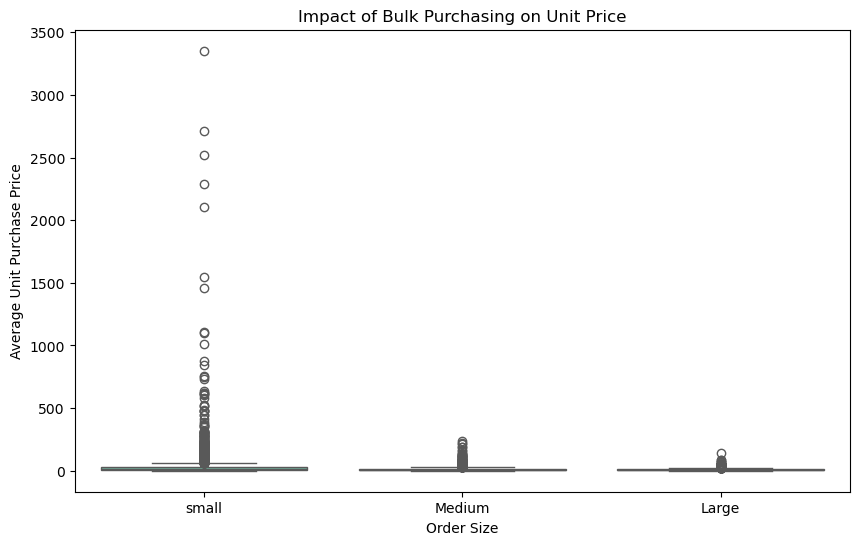

In [91]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="OrderSize", y="UnitPurchasePrice", palette="Set2")
plt.title("Impact of Bulk Purchasing on Unit Price")
plt.xlabel("Order Size")
plt.ylabel("Average Unit Purchase Price")
plt.show()

* Vendors buying in bulk (Large Order Size) get the lowest unit price ($10.78 per unit),meaning higher margins if they can manage inventory efficiently.
* The price difference between Small and Large orders is substantial(~72% reduction in unit cost)
* This suggests that bulk pricing strategies successfully encourage vendors to purchase in larger volumes,leading to higher to higher overall sales despite lower per-unit revenue.

### Which vendors have low inventory turnover, indicating excess stock and slow-moving products?

In [45]:
df[df['StockTurnover']<1].groupby('VendorName')[['StockTurnover']].mean().sort_values('StockTurnover',ascending = True).head(10)

,StockTurnover
VendorName,
TRUETT HURST,0.041667
"IRA GOLDMAN AND WILLIAMS, LLP",0.075000
VINEYARD BRANDS LLC,0.180533
UNCORKED,0.217238
LOYAL DOG WINERY,0.279167
BLACK COVE BEVERAGES,0.327530
Serralles Usa LLC,0.383948
GILMANTON WINERY & VINEYARD,0.428842
APPOLO VINEYARDS LLC,0.445833


### How much capital is locked in unsold inventory per vendor,and which vendors contribute the most to it?

In [46]:
df['UnsoldInventoryValue'] = (df["TotalPurchaseQuantity"] - df["TotalSalesQuantity"]) * df["PurchasePrice"]
print('Total Unsold Capital:', fromat_dollars(df["UnsoldInventoryValue"].sum()))

Total Unsold Capital: 17.91M


In [48]:
# Aggregate Capital Locked per Vendor
inventory_value_per_vendor = df.groupby("VendorName")["UnsoldInventoryValue"].sum().reset_index()

# Sort Vendors with the Highest Locked Capital
inventory_value_per_vendor = inventory_value_per_vendor.sort_values(by="UnsoldInventoryValue", ascending=False)
inventory_value_per_vendor['UnsoldInventoryValue'] = inventory_value_per_vendor['UnsoldInventoryValue'].apply(fromat_dollars)

inventory_value_per_vendor.head(10)

,VendorName,UnsoldInventoryValue
28,DIAGEO NORTH AMERICA INC,2.54M
63,MARTIGNETTI COMPANIES,1.72M
50,JIM BEAM BRANDS COMPANY,1.50M
75,PERNOD RICARD USA,1.29M
115,ULTRA BEVERAGE COMPANY LLP,1.01M
59,M S WALKER INC,736.99k
74,PERFECTA WINES,725.86k
14,BROWN-FORMAN CORP,695.76k
33,E & J GALLO WINERY,675.95k
23,CONSTELLATION BRANDS INC,665.37k


### What is the 90% confidence intervals for profit margins of top-performing and low-performing vendors

In [50]:
top_threshold = df["TotalSalesDollars"].quantile(0.75)
low_threshold = df["TotalSalesDollars"].quantile(0.25)

In [76]:
top_vendors = top_vendors[top_vendors >= 0]
low_vendors = low_vendors[low_vendors >= 0]

In [81]:
low_vendors

7377      2.272098
7390      1.390944
7404      2.211703
7409      2.899252
7473      9.251760
           ...    
10686    89.806174
10687    83.448276
10688    96.436186
10690    98.929430
10691    99.166079
Name: ProfitMargin, Length: 1580, dtype: float64

In [78]:

def confidence_interval(data, confidence=0.95):
    mean_val = np.mean(data)
    std_err = np.std(data, ddof=1) / np.sqrt(len(data)) # standard error
    t_critical = stats.t.ppf((1 + confidence) / 2, df=len(data) - 1)
    margin_of_error = t_critical * std_err
    return mean_val, mean_val - margin_of_error, mean_val + margin_of_error

Top Vendors 95% CI: (29.29, 30.14), Mean: 29.71
low Vendors 95% CI: (38.26, 40.61), Mean: 39.43


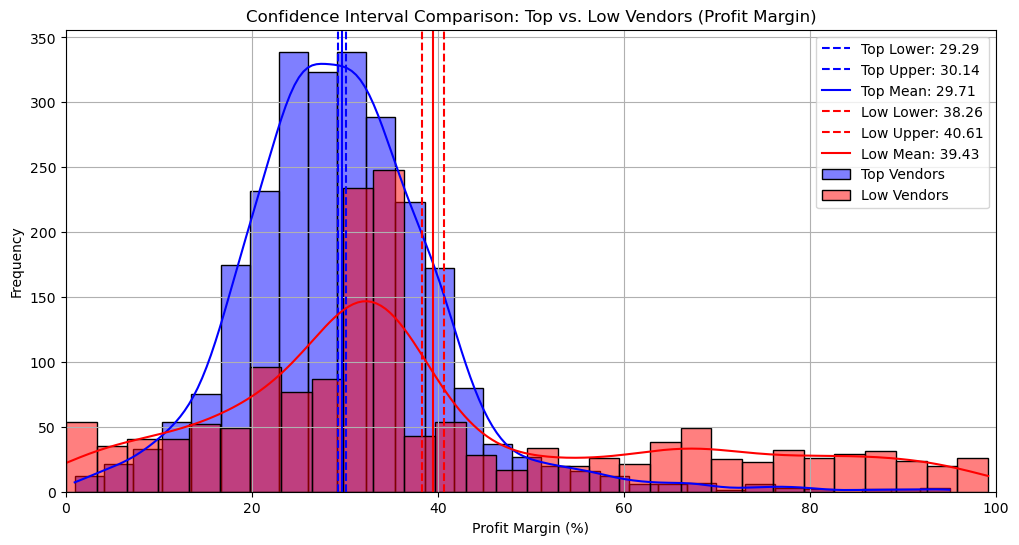

In [80]:
top_mean, top_lower, top_upper = confidence_interval(top_vendors)
low_mean, low_lower, low_upper = confidence_interval(low_vendors)

print(f"Top Vendors 95% CI: ({top_lower:.2f}, {top_upper:.2f}), Mean: {top_mean:.2f}")
print(f"low Vendors 95% CI: ({low_lower:.2f}, {low_upper:.2f}), Mean: {low_mean:.2f}")

plt.figure(figsize=(12, 6))

# Top Vendors plot
sns.histplot(top_vendors, kde=True, color="blue", bins=30, alpha=0.5, label="Top Vendors")
plt.axvline(top_lower, color="blue", linestyle="--", label=f"Top Lower: {top_lower:.2f}")
plt.axvline(top_upper, color="blue", linestyle="--", label=f"Top Upper: {top_upper:.2f}")
plt.axvline(top_mean, color="blue", linestyle="-", label=f"Top Mean: {top_mean:.2f}")

# Low Vendors Plot
sns.histplot(low_vendors, kde=True, color="red", bins=30, alpha=0.5, label="Low Vendors")
plt.axvline(low_lower, color="red", linestyle="--", label=f"Low Lower: {low_lower:.2f}")
plt.axvline(low_upper, color="red", linestyle="--", label=f"Low Upper: {low_upper:.2f}")
plt.axvline(low_mean, color="red", linestyle="-", label=f"Low Mean: {low_mean:.2f}")

# Finalize Plot
plt.title("Confidence Interval Comparison: Top vs. Low Vendors (Profit Margin)")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Frequency")
plt.xlim(0, 100)
plt.xticks(range(0, 101, 20))
plt.legend()
plt.grid(True)
plt.show()

* The confidence interval for low-performing vendors(38.26% to 40.61%) is significant higher than of top-performing vendors(29.29% to 30.14%).
* This suggests that vendors with lower sales tend to maintain higher profit margins,potentially due to premium pricing or lower operational costs.
* For High-Performing Vendors: If they aim to improve profitability,they could explore selective price adjustments, cost optimization, or bundling strategies
* For Low_Performing Vendors : Despite higher margins,their low sales volume might indicate a need for better marketing,competitive pricing, or improved distribution strategies

### Is there a significant difference in profit margins between top-performing and low-performing vendors?

Hypothesis:

H0 (Null Hypothesis): There is no significant difference in the mean profit margins of top-performing and low-performing vendors.

H1 (Alternative Hypothesis): The mean profit margins of top-performing and low-performing vendors are significantly different.

In [82]:
top_threshold = df["TotalSalesDollars"].quantile(0.75)
low_threshold = df["TotalSalesDollars"].quantile(0.25)

top_vendors = top_vendors[top_vendors >= 0]
low_vendors = low_vendors[low_vendors >= 0]

# Perform Two-Sample T-Test
t_stat, p_value = ttest_ind(top_vendors, low_vendors, equal_var=False)

# Print results
print(f"T-Statistic : {t_stat:.4f}, P-Value: {p_value:.4f}")
if p_value < 0.05:
    print("Reject H0: There is significant difference in profit margin between top and low-performing vendors.")
else :
    print("Fail to Reject H0: No significant difference in profit margins")

T-Statistic : -15.2108, P-Value: 0.0000
Reject H0: There is significant difference in profit margin between top and low-performing vendors.


In [84]:
df.to_csv("Desktop/vendor_sales_summary.csv", index=False)